## Knowledge distilation process

Distillation is a technique that helps reduce the model size, which ultimately reduces the number of computations and improves model inference performance. Distillation uses statistical methods to train a smaller student model on a larger teacher model. The end result is a student model that retains a high percentage of the teacher’s model accuracy but uses a much smaller number of parameters. The student model is then deployed for inference. The smaller model requires smaller hardware and therefore less cost per inference request.<br>

The teacher model is often a generative foundation model or a fine-tuned variant. During the distillation training process, the student model learns to statistically replicate the behavior of the teacher model. Note that the teacher model weights do not change during the distillation process—only the student model weights change. The teacher model’s output is used to “distill” knowledge to the student model.<br>

Both the teacher and student models generate completions from a prompt-based training dataset. A distillation loss is calculated by comparing the two completions and calculating the KL divergence between the teacher and student output distributions.<br>

The loss—including KL divergence—is then minimized during the distillation process using backpropagation to improve the student model’s ability to match the teacher model’s predicted next-token probability distribution.

The teacher models’ predicted tokens are known as soft labels, while the student models’ predicted tokens are called soft predictions. In parallel, you need to compare the student models’ predictions (hard predictions) against the ground truth hard labels from the prompt dataset. The difference is the student loss. The distillation loss and student loss are combined and used to update the student models’ weights using standard backpropagation.

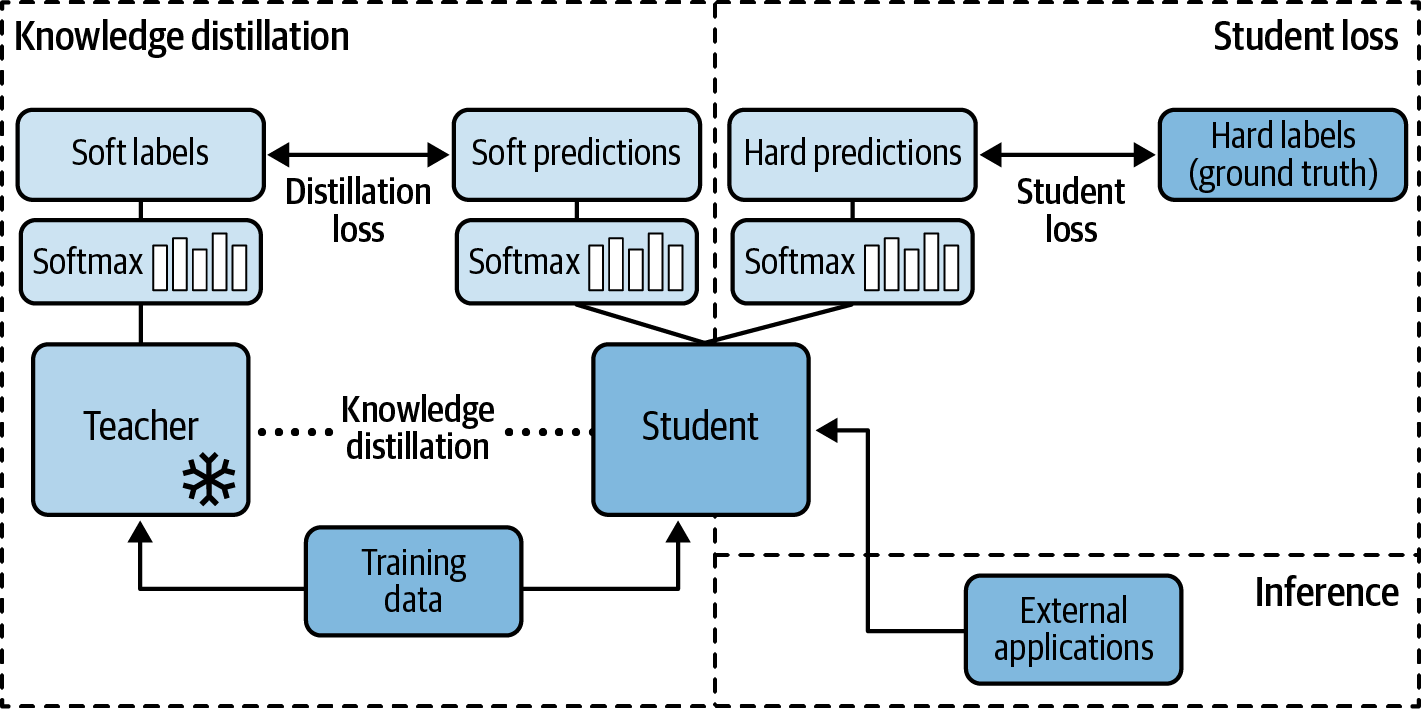

In practice, distillation may not be as effective for generative decoder models as it is for encoder models like BERT. This is because the output space is relatively large for decoder models (with a vocabulary size of, e.g., 100,000 tokens) without a lot of redundancy in representation.

In [ ]:
def compute_distillation_loss(self, inputs, student_outputs):
    with torch.no_grad():
        teacher_outputs = self.teacher(**inputs)

    temperature = self.args.distillation_temperature

    distilliation_loss_start = F.kl_div(
      input=F.log_softmax(
        student_outputs.start_logits / temperature, dim=-1),
      target=F.softmax(
        teacher_outputs.start_logits / temperature, dim=-1),
      reduction="batchmean",
    ) * (temperature**2)

    distilliation_loss_end = F.kl_div(
        input=F.log_softmax(
          student_outputs.end_logits / temperature, dim=-1),
        target=F.softmax(
          teacher_outputs.end_logits / temperature, dim=-1),
        reduction="batchmean",
    ) * (temperature**2)

    return (distilliation_loss_start + distilliation_loss_end) / 2.0